In [1]:
!nvidia-smi

Sun Apr 19 10:05:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   38C    P8              3W /   83W |      20MiB /   8151MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

def check_cuda():
    print("=== PyTorch CUDA Diagnostic ===\n")

    # 1. Is CUDA available?
    cuda_available = torch.cuda.is_available()
    print(f"CUDA available: {cuda_available}")

    # 2. PyTorch build info
    print(f"PyTorch version: {torch.__version__}")
    print(f"CUDA version (torch): {torch.version.cuda}")

    if not cuda_available:
        print("\n[FAIL] CUDA is not available.")
        return

    # 3. GPU details
    device_count = torch.cuda.device_count()
    print(f"\nNumber of GPUs: {device_count}")

    for i in range(device_count):
        print(f"\n--- GPU {i} ---")
        print(f"Name: {torch.cuda.get_device_name(i)}")
        print(f"Capability: {torch.cuda.get_device_capability(i)}")
        print(f"Memory Allocated: {torch.cuda.memory_allocated(i)} bytes")
        print(f"Memory Reserved: {torch.cuda.memory_reserved(i)} bytes")

    # 4. Actual computation test (this is the only *real* proof)
    try:
        device = torch.device("cuda:0")
        x = torch.rand(3, 3).to(device)
        y = torch.rand(3, 3).to(device)
        z = x @ y

        print("\n[OK] Tensor computation on GPU succeeded.")
        print(f"Result device: {z.device}")

    except Exception as e:
        print("\n[FAIL] CUDA exists but computation failed.")
        print(f"Error: {e}")


if __name__ == "__main__":
    check_cuda()

=== PyTorch CUDA Diagnostic ===

CUDA available: True
PyTorch version: 2.12.0.dev20260324+cu128
CUDA version (torch): 12.8

Number of GPUs: 1

--- GPU 0 ---
Name: NVIDIA GeForce RTX 5060 Laptop GPU
Capability: (12, 0)
Memory Allocated: 0 bytes
Memory Reserved: 0 bytes

[OK] Tensor computation on GPU succeeded.
Result device: cuda:0


## Dataset Unzip

In [5]:
from pathlib import Path
import zipfile

# Paths
ROOT = Path.cwd().parent.parent
DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH_ZIP = DATA_DIR / "Mosquitoes_dataset.zip"
EXTRACT_DIR = DATA_DIR / "Mosquitoes_dataset"

In [6]:
# Unzip
with zipfile.ZipFile(DATASET_PATH_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Extracted to: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset


## Dataset inspection

In [7]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent.parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH = DATA_DIR / "Mosquitoes_dataset"

In [8]:
import os
os.listdir(DATASET_PATH)

['data.yaml',
 'README.dataset.txt',
 'README.roboflow.txt',
 'test',
 'train',
 'valid']

In [9]:
DATASET_PATH_YAML = DATASET_PATH / "data.yaml"

with open(DATASET_PATH_YAML, 'r') as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['0']

roboflow:
  workspace: mosquitos-4tgsz
  project: mos_and_nonmos-2
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/mosquitos-4tgsz/mos_and_nonmos-2/dataset/1


In [10]:
import os
from collections import defaultdict

def analizar_dataset_yolo_roboflow(dataset_path):
    splits = ['train', 'valid', 'test']
    ext_img = ('.jpg', '.jpeg', '.png')

    total_imgs = 0
    split_counts = {}
    class_counts = defaultdict(int)
    all_classes = set()

    print(f"\n Analyzing dataset in: {dataset_path}\n")

    for split in splits:
        images_dir = os.path.join(dataset_path, split, "images")
        labels_dir = os.path.join(dataset_path, split, "labels")

        if not os.path.exists(images_dir):
            print(f" No se encontró la carpeta {images_dir}")
            continue

        images = [f for f in os.listdir(images_dir) if f.lower().endswith(ext_img)]
        split_counts[split] = len(images)
        total_imgs += len(images)

        for img in images:
            base_name = os.path.splitext(img)[0]
            label_file = base_name + '.txt'
            label_path = os.path.join(labels_dir, label_file)
            if os.path.exists(label_path):
                with open(label_path, 'r') as f:
                    lines = f.readlines()
                    for line in lines:
                        cls_id = line.strip().split()[0]
                        class_counts[cls_id] += 1
                        all_classes.add(cls_id)

    print(" Dataset Statistics:")
    print(f"   - Total images: {total_imgs}")
    for split in splits:
        count = split_counts.get(split, 0)
        pct = (count / total_imgs * 100) if total_imgs > 0 else 0
        print(f"   - {split.capitalize():<6}: {count} images ({pct:.2f}%)")

    print("\n Classes found:")
    if all_classes:
        sorted_classes = sorted(all_classes, key=lambda x: int(x))
        for cls_id in sorted_classes:
            print(f"   - Class {cls_id}: {class_counts[cls_id]} images")
    else:
        print("   - No se encontraron clases (verifica los archivos .txt)")

analizar_dataset_yolo_roboflow(DATASET_PATH)


 Analyzing dataset in: c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset

 Dataset Statistics:
   - Total images: 22309
   - Train : 19530 images (87.54%)
   - Valid : 1400 images (6.28%)
   - Test  : 1379 images (6.18%)

 Classes found:
   - Class 0: 17140 images


## Optuna Study inspection

In [11]:
import optuna

study = optuna.load_study(
    study_name="yolo_search",
    storage="sqlite:///optuna.db"
)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

c:\Users\lucas\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Best value: 0.9632916441628662
Best params: {'lr0': 0.048117056448515556, 'lrf': 0.10572865615957065, 'momentum': 0.805892487977318, 'weight_decay': 8.671311282524392e-05, 'warmup_epochs': 1.7207575123688748, 'box': 0.07140798031378946, 'cls': 0.46312589434355633, 'dfl': 1.3127070468937196, 'hsv_h': 0.017351360216514393, 'hsv_s': 0.6971630715901096, 'hsv_v': 0.3213744936509859, 'flipud': 0.2882519808308238, 'fliplr': 0.5636196176412798, 'mosaic': 0.5937355916148969, 'mixup': 0.09972237348000992}


In [12]:
for t in study.trials:
    print(t.number, t.value, t.params)

0 0.9499312583413585 {'lr0': 0.001107225705076054, 'lrf': 0.26452086309946793, 'momentum': 0.8246494983394298, 'weight_decay': 0.0005767614917142247, 'warmup_epochs': 2.7179864005964096, 'box': 0.10152990802542688, 'cls': 0.41166019044286106, 'dfl': 1.4590819991684483, 'hsv_h': 0.035067519575729005, 'hsv_s': 0.4423464487411177, 'hsv_v': 0.3997584247097817, 'flipud': 0.2949539186584882, 'fliplr': 0.5924605095141455, 'mosaic': 0.6905465830820443, 'mixup': 0.1702105633114431}
1 0.9401290506795612 {'lr0': 0.0009289066520681525, 'lrf': 0.32843587997380486, 'momentum': 0.9703200748012986, 'weight_decay': 8.034482834856468e-05, 'warmup_epochs': 1.0967336882555498, 'box': 0.07305614794850487, 'cls': 0.4138931543735102, 'dfl': 0.987816068558496, 'hsv_h': 0.04314520425505195, 'hsv_s': 0.45902856853077706, 'hsv_v': 0.7140298516912418, 'flipud': 0.1963688914837306, 'fliplr': 0.3384361732487288, 'mosaic': 0.9938998121240741, 'mixup': 0.24280916677314696}
2 0.944327321258607 {'lr0': 0.00389880050945

In [13]:
import pandas as pd

df = study.trials_dataframe()

print(df.head())

df.to_csv("trials.csv", index=False)

   number     value             datetime_start          datetime_complete  \
0       0  0.949931 2026-03-27 11:52:51.686066 2026-03-27 12:18:19.299928   
1       1  0.940129 2026-03-27 12:18:19.316008 2026-03-27 14:24:54.717375   
2       2  0.944327 2026-03-27 14:24:54.730542 2026-03-27 15:44:15.381627   
3       3  0.944417 2026-03-27 15:44:15.424457 2026-03-27 16:32:19.263278   
4       4  0.947703 2026-03-27 16:32:19.279367 2026-03-27 17:54:35.875592   

                duration  params_box  params_cls  params_dfl  params_fliplr  \
0 0 days 00:25:27.613862    0.101530    0.411660    1.459082       0.592461   
1 0 days 02:06:35.401367    0.073056    0.413893    0.987816       0.338436   
2 0 days 01:19:20.651085    0.129973    0.250734    1.181527       0.456745   
3 0 days 00:48:03.838821    0.129878    0.509093    1.112984       0.373780   
4 0 days 01:22:16.596225    0.082377    0.449465    1.394940       0.655128   

   params_flipud  ...  params_hsv_s  params_hsv_v  params_lr0 

C:\Users\lucas\AppData\Local\Temp\ipykernel_25772\3698746423.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_optimization_history(study)


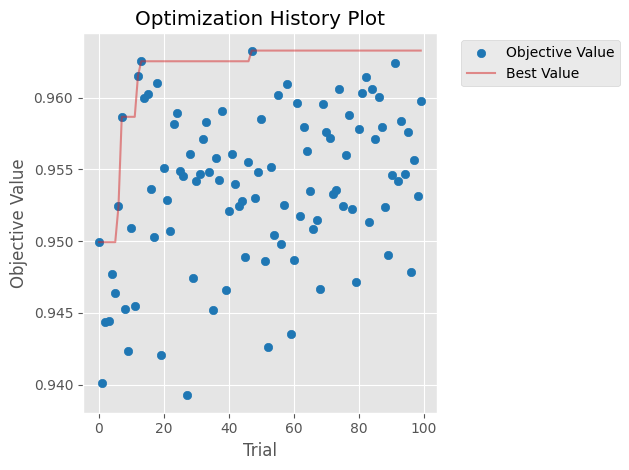

In [14]:
import optuna.visualization.matplotlib as vis
import matplotlib.pyplot as plt

fig = vis.plot_optimization_history(study)

plt.savefig("history.png")
plt.show()

C:\Users\lucas\AppData\Local\Temp\ipykernel_25772\345558694.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_param_importances(study)


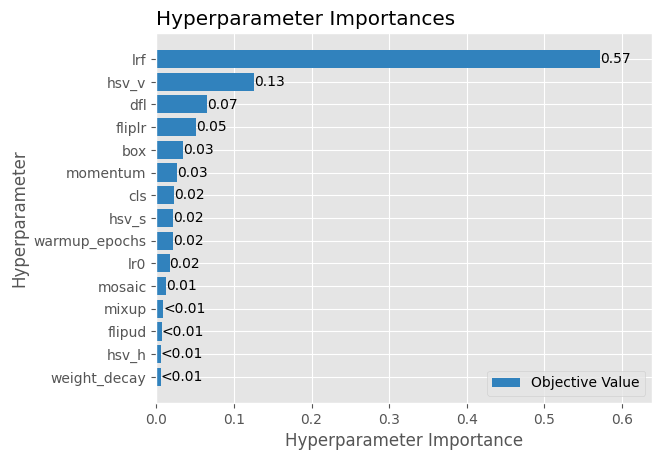

In [15]:
fig = vis.plot_param_importances(study)

plt.savefig("importance.png")
plt.show()

C:\Users\lucas\AppData\Local\Temp\ipykernel_25772\1963374525.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_parallel_coordinate(study)


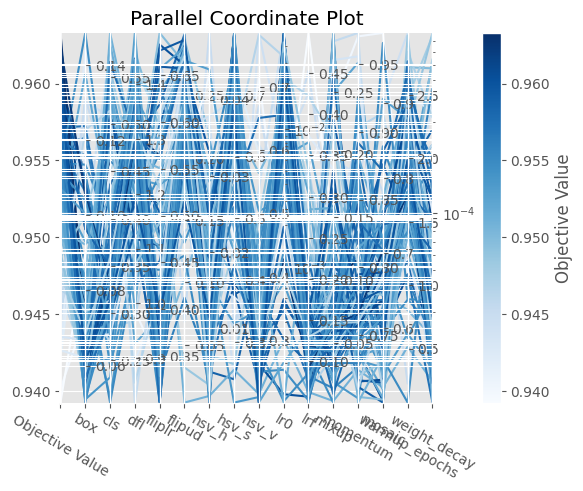

In [16]:
fig = vis.plot_parallel_coordinate(study)

plt.show()

C:\Users\lucas\AppData\Local\Temp\ipykernel_25772\1235612825.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_contour(study)


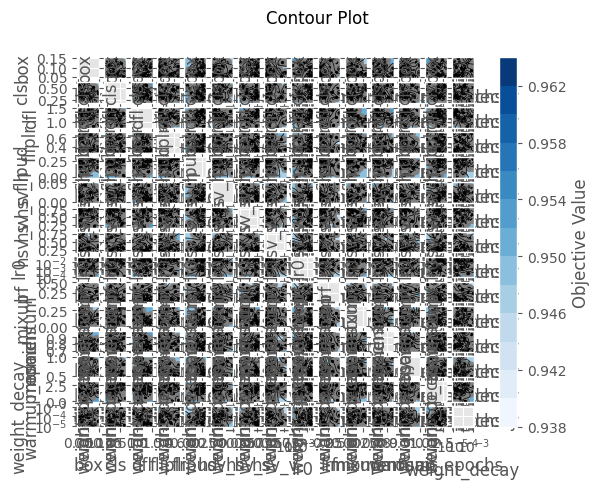

In [17]:
fig = vis.plot_contour(study)

plt.show()

In [18]:
print(len(study.trials))

100


C:\Users\lucas\AppData\Local\Temp\ipykernel_52220\368495961.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = vis.plot_optimization_history(study)


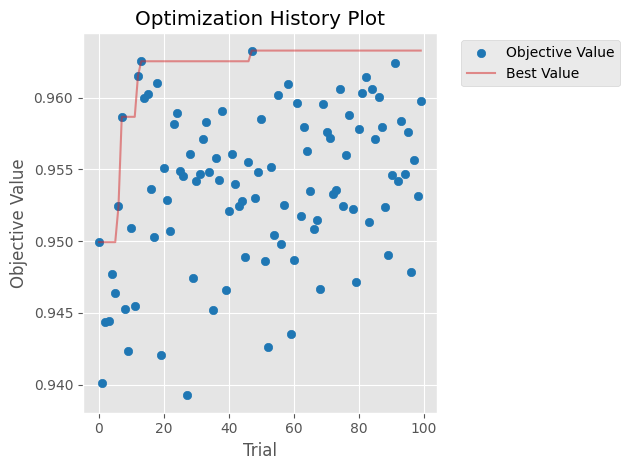

In [11]:
import optuna.visualization.matplotlib as vis
import matplotlib.pyplot as plt

fig = vis.plot_optimization_history(study)

plt.savefig("history.png", dpi=300)
plt.show()

In [19]:
import optuna
import yaml

DB = "sqlite:///optuna.db"
STUDY = "yolo_search"

study = optuna.load_study(
    study_name=STUDY,
    storage=DB
)

best_params = study.best_params

print("Best params found:")
for k, v in best_params.items():
    print(k, "=", v)

with open("best_hyp.yaml", "w") as f:
    yaml.dump(best_params, f)

print("Saved best_hyp.yaml")

Best params found:
lr0 = 0.048117056448515556
lrf = 0.10572865615957065
momentum = 0.805892487977318
weight_decay = 8.671311282524392e-05
warmup_epochs = 1.7207575123688748
box = 0.07140798031378946
cls = 0.46312589434355633
dfl = 1.3127070468937196
hsv_h = 0.017351360216514393
hsv_s = 0.6971630715901096
hsv_v = 0.3213744936509859
flipud = 0.2882519808308238
fliplr = 0.5636196176412798
mosaic = 0.5937355916148969
mixup = 0.09972237348000992
Saved best_hyp.yaml


## Yolo Model inspection

In [22]:
from ultralytics import YOLO

model = YOLO("best.pt")

In [23]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent.parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH = DATA_DIR / "Mosquitoes_dataset"

DATASET_PATH_YAML = DATASET_PATH / "data.yaml"

metrics = model.val(data=DATASET_PATH_YAML)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.26  Python-3.12.10 torch-2.12.0.dev20260324+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 308.0233.1 MB/s, size: 24.1 KB)
val: Scanning C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\valid\labels... 1400 images, 491 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1400/1400 3.5Kit/s 0.4ss
val: New cache created: C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\valid\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 88/88 21.4it/s 4.1s0.0s
                   all       1400       1098      0.955      0.958      0.977      0.735
Speed: 0.2ms preprocess, 1.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Use

In [24]:
from pathlib import Path

# Path
ROOT = Path.cwd().parent.parent

DATA_DIR = ROOT / "0_Datasets"

DATASET_PATH = DATA_DIR / "Mosquitoes_dataset"

DATASET_VALID_IMAGES_PATH = DATASET_PATH / "valid" / "images"

model.predict(
    source=DATASET_VALID_IMAGES_PATH,
    imgsz=256,
    device=0
)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1400 c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\valid\images\-_-_-_jpg.rf.10a81569be6d8e612163cbab580172a0.jpg: 256x256 (no detections), 4.8ms
image 2/1400 c:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\0_Datasets\Mosquitoes_dataset\valid\images\-_4-1-_jpg.rf.d68ae6bedcb07f6cd0c6ea1f2c37a06a.jpg: 256x256 (no detections), 4.1ms
image 3/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255

## ONNX Export

In [27]:
model.export(
    format="onnx",
    imgsz=256,
    dynamic=False,
    simplify=False,   # critical
    opset=12
)

Ultralytics 8.4.26  Python-3.12.10 torch-2.12.0.dev20260324+cu128 CPU (Intel Core i7-14650HX)

PyTorch: starting from 'best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) (1, 5, 1344) (21.5 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: export success  2.1s, saved as 'best.onnx' (42.5 MB)

Export complete (2.2s)
Results saved to C:\Users\lucas\Desktop\Trabajo Final de Grado\TFG PinMartinez\New folder (2) - Copy\NEW\Trainers\Yolo_Trainer
Predict:         yolo predict task=detect model=best.onnx imgsz=256 
Validate:        yolo val task=detect model=best.onnx imgsz=256 data=dataset/data.yaml  
Visualize:       https://netron.app


'best.onnx'